# (노트) Pytorch Logistic Regression 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

In [797]:
import torch 
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

### EX1

`-` 현실에서 이런경우가 많음: 
- $x$가 커질수록 (작아질수록) 성공확률이 증가 

`-` 이러한 모형은 아래와 같이 설계할 수 있음 (왜?) <--- 외우세요.. !!! 

- $y_i \sim Ber(p_i),\quad $ where $p_i=\frac{\exp(\beta_0+\beta_1x_i)}{1+\exp(\beta_0+\beta_1x_i)}$


- $\hat{y}_i= \frac{\exp(\hat{\beta}_0+\hat{\beta}_1 x_i)}{1+\exp(\hat{\beta}_0+\hat{\beta}_1x_i)}=\frac{1}{1+\exp(-\hat{\beta}_0-\hat{\beta}_1x_i)}$

- $loss=  -\sum_{i=1}^{n}\big(y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i) \big)$ <--- 외우세요!!

In [887]:
torch.manual_seed(1)
X=torch.linspace(-1,1,2000).reshape(2000,1)
w0= -1
w1= 5
u=X*w1+w0
v=torch.exp(u)/(1+(torch.exp(u)+1))
y=torch.bernoulli(v)

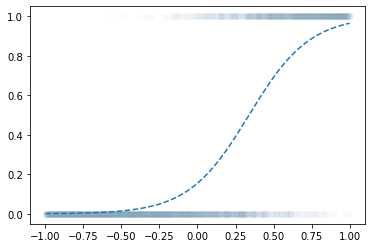

In [888]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,v,'--')

`-` 다이어그램으로 표현하면? 

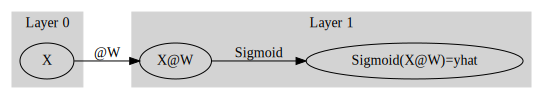

In [889]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "X@W"[label="@W"]
    "X@W" -> "Sigmoid(X@W)=yhat"[label="Sigmoid"]
    label = "Layer 1"
}
''')

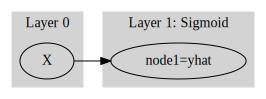

In [890]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    X
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    X -> "node1=yhat"
    label = "Layer 1: Sigmoid"
}
''')

`-` 아키텍쳐, 손실함수, 옵티마이저

In [891]:
torch.manual_seed(43052)
l1=torch.nn.Linear(in_features=1,out_features=1,bias=True)
a1=torch.nn.Sigmoid() 
net=torch.nn.Sequential(l1,a1)
#loss=torch.mean((y-yhat)**2)????? <-- 이거 아닙니다!! 
optimizer=torch.optim.SGD(net.parameters(),lr=0.05)

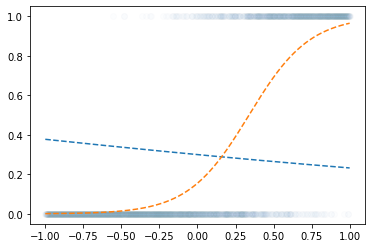

In [892]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,net(X).data,'--')
plt.plot(X,v,'--')

`-` step1~4

In [893]:
for epoc in range(10000):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=-torch.mean(y*torch.log(yhat)+(1-y)*torch.log(1-yhat))
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

In [894]:
list(net.parameters())

[Parameter containing:
 tensor([[4.9756]], requires_grad=True),
 Parameter containing:
 tensor([-1.6564], requires_grad=True)]

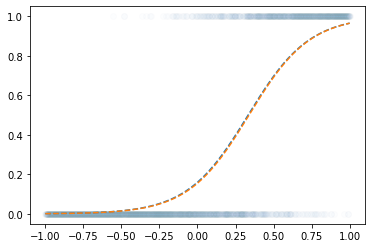

In [895]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,yhat.data,'--')
plt.plot(X,v,'--')

### 숙제 

loss를 mse로 바꿔서 돌려볼것 

In [896]:
torch.manual_seed(43052)
l1=torch.nn.Linear(in_features=1,out_features=1,bias=True)
a1=torch.nn.Sigmoid() 
net=torch.nn.Sequential(l1,a1)
#loss=torch.mean((y-yhat)**2)????? <-- 이거 아닙니다!! 
optimizer=torch.optim.SGD(net.parameters(),lr=0.05)

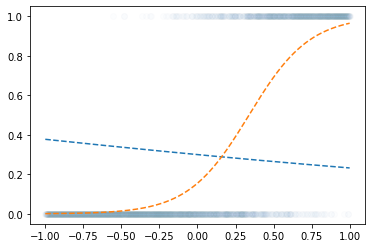

In [897]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,net(X).data,'--')
plt.plot(X,v,'--')

`-` step1~4

In [898]:
for epoc in range(10000):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=torch.mean((y-yhat)**2)
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

In [899]:
list(net.parameters())

[Parameter containing:
 tensor([[4.1858]], requires_grad=True),
 Parameter containing:
 tensor([-1.3823], requires_grad=True)]

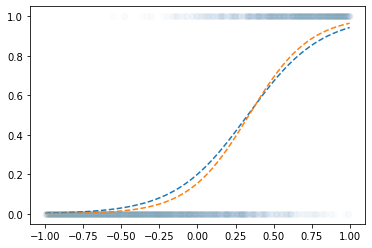

In [900]:
plt.scatter(X,y,alpha=0.01)
plt.plot(X,yhat.data,'--')
plt.plot(X,v,'--')

### MSEloss 와 binary cross entropy 비교

In [1905]:
import numpy as np

In [1906]:
torch.manual_seed(1)
X=torch.linspace(-1,1,2000).reshape(2000,1)
w0= -1
w1= 5
u=X*w1+w0
v=torch.exp(u)/(1+(torch.exp(u)+1))
y=torch.bernoulli(v)

In [1907]:
import pandas as pd 

In [1908]:
_w0 = np.arange(-10, 3, 0.05)
_w1 = np.arange(-1, 10, 0.05)
_w0,_w1 = np.meshgrid(_w0,_w1,indexing='ij')

In [1909]:
_w0=_w0.reshape(-1)
_w1=_w1.reshape(-1)

In [1910]:
def loss_crossenp(w0,w1): 
    yhat= torch.exp(w0+w1*X)/(1+torch.exp(w0+w1*X))
    loss=- torch.mean((y*torch.log(yhat) + (1-y)*torch.log(1-yhat)))
    return loss.tolist()
def loss_mse(w0,w1):
    yhat= torch.exp(w0+w1*X)/(1+torch.exp(w0+w1*X))
    loss=torch.mean((y-yhat)**2)
    return loss.tolist()

In [1911]:
_l1=list(map(loss_crossenp,_w0,_w1))
_l2=list(map(loss_mse,_w0,_w1))

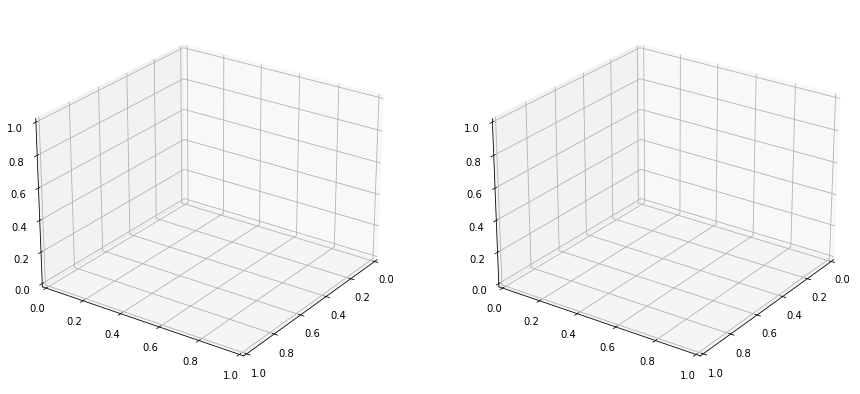

In [1912]:
fig = plt.figure()
ax1= fig.add_subplot(1,2,1,projection='3d')
ax2= fig.add_subplot(1,2,2,projection='3d')
ax1.elev = 25
ax2.elev = 25
ax1.azim = 35
ax2.azim = 35
fig.set_figheight(15)
fig.set_figwidth(15)

In [1913]:
_w0[np.argmin(_l1)],_w1[np.argmin(_l1)]

(-1.6499999999998813, 5.000000000000005)

In [1914]:
loss_crossenp(_w0[np.argmin(_l1)],_w1[np.argmin(_l1)])

0.3093094527721405

In [1915]:
_l1[np.argmin(_l1)]

0.3093094527721405

In [1916]:
np.min(_l1)

0.3093094527721405

In [1917]:
_w0[np.argmin(_l2)],_w1[np.argmin(_l2)]

(-1.5999999999998806, 4.800000000000005)

In [1918]:
ax1.scatter(_w0,_w1,_l1,s=0.05)
ax2.scatter(_w0,_w1,_l2,s=0.05)
ax1.scatter(-10,-1,loss_crossenp(-10,-1),color='gray')
ax1.scatter(-1,5,loss_crossenp(-1,5),s=200,color='red',marker='*')
ax1.scatter(_w0[np.argmin(_l1)],_w1[np.argmin(_l1)],loss_crossenp(_w0[np.argmin(_l1)],_w1[np.argmin(_l1)]),s=200,color='red',marker='x')
ax2.scatter(-10,-1,loss_mse(-10,-1),color='gray')
ax2.scatter(-1,5,loss_mse(-1,5),s=200,color='red',marker='*')
ax2.scatter(_w0[np.argmin(_l2)],_w1[np.argmin(_l2)],loss_mse(_w0[np.argmin(_l2)],_w1[np.argmin(_l2)]),s=200,color='red',marker='x')

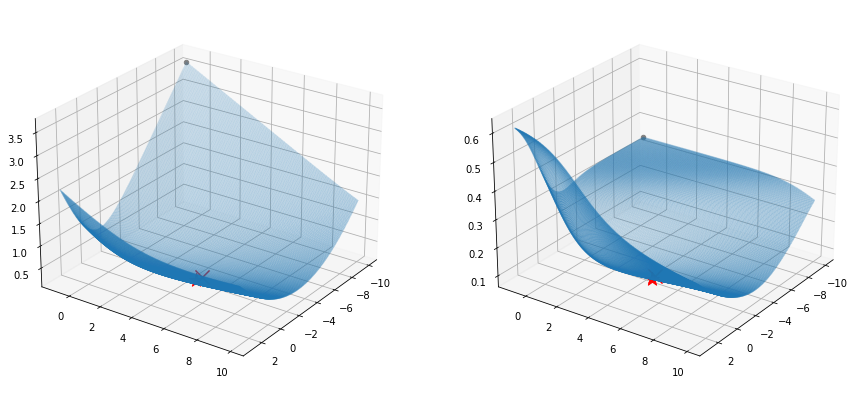

In [1919]:
fig

#### 수렴과정을 애니메이션으로 확인해보자. 

In [1928]:
losses=[]
for epoc in range(10000):
    ## 1 
    yhat=net(X) 
    ## 2 
    loss=torch.mean((y-yhat)**2)
    losses.append(loss.item())
    ## 3 
    loss.backward()
    ## 4 
    optimizer.step()
    net.zero_grad()

In [ ]:
# Set up a figure twice as tall as it is wide
fig = plt.figure()

# First subplot
ax1 = fig.add_subplot(1, 2, 1)
# Second subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

## ax1
ax1.plot(x,y,'o')
line, = ax1.plot(x,yhats[0])

## ax2
_w0 = np.arange(-6, 11, 0.5)
_w1 = np.arange(-6, 11, 0.5)
w0,w1 = np.meshgrid(_w0,_w1,indexing='ij')
l=w0*0
for i in range(len(_w0)):
    for j in range(len(_w1)):
        l[i,j]=torch.mean((y-_w0[i]-_w1[j]*x)**2)

ax2.plot_surface(w0, w1, l, rstride=1, cstride=1, color='b',alpha=0.35)

ax2.scatter(2.5,4,torch.mean((y-2.5-4*x)**2),s=200,color='red',marker='*')
ax2.scatter(np.array(Whats)[0,0],np.array(Whats)[0,1],losses[0],color='b')
ax2.azim = 40
ax2.dist = 8
ax2.elev = 5
#ax2.plot(Whats[0:2][0],Whats[0:2][1],torch.mean((y-Whats[0:2][0]-Whats[0:2][1]*x)**2), linestyle="dashed",linewidth=2,color="grey")
         
def animate(i):
    line.set_ydata(yhats[i])
    ax2.scatter(np.array(Whats)[i,0],np.array(Whats)[i,1],losses[i],color='grey')
    return line

ani = animation.FuncAnimation(fig, animate, frames=30)
plt.close()
ani

`-` MSE vs BCE